In [3]:
import pandas as pd

# Load the dataset provided by the user
file_path = "/content/drive/MyDrive/Fastrack Bootcamp Data Analysis BayData Market/Tugas/dataset_review_bebek_palupi_rungkut_v2.csv"
df_reviews = pd.read_csv(file_path, encoding='latin1')
df_reviews.head()

,No,Platform,Review,Customer ID
0,0,Google Review,"kalau bicara kuliner bebek goreng di surabaya,...",CUST0001
1,1,Google Review,tampilan dari luar memang agak kumuh. halaman ...,CUST0002
2,2,Google Review,"bebek empuk, rasanya ok lah. bumbu bebek jg en...",CUST0003
3,3,Google Review,sudah lama penasaran buat cobain bebek goreng ...,CUST0004
4,4,Google Review,tempat makan bebek yg enak dan rameee pool dis...,CUST0005


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import library NLP
import nltk #Library utama untuk pemrosesan teks dalam NLP.
from nltk.tokenize import word_tokenize #Memecah teks menjadi kata-kata (tokenization).
from nltk.corpus import stopwords #Berisi daftar kata umum yang tidak memiliki banyak makna (misalnya: "dan", "adalah").
from collections import Counter #Menghitung jumlah kemunculan kata dalam teks.
import string #Untuk menghapus tanda baca.
import re #Library untuk pemrosesan teks menggunakan ekspresi reguler (regex).
from wordcloud import WordCloud #Membuat visualisasi word cloud dari teks.
import matplotlib.pyplot as plt #Untuk menampilkan grafik dan visualisasi.
from sklearn.feature_extraction.text import TfidfVectorizer #Mengubah teks menjadi representasi numerik berbasis TF-IDF.
from sklearn.decomposition import LatentDirichletAllocation #Model untuk topik modeling (menemukan topik dalam teks).

# Download stopwords bahasa Indonesia jika belum ada
nltk.download('stopwords') #Berisi daftar kata-kata umum dalam berbagai bahasa yang biasanya tidak perlu dianalisis.
nltk.download('punkt') #Model pre-trained untuk melakukan tokenisasi (pemisahan kata dalam teks).
nltk.download('punkt_tab') # TModel pre-trained untuk melakukan tokenisasi (pemisahan kata dalam teks).

# Menggunakan stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian')) # Mengubah daftar stopwords menjadi set untuk pencarian yang lebih cepat.

# Preprocessing Teks
def clean_text(text):
    text = text.lower()  # Konversi ke huruf kecil
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hapus tanda baca
    tokens = word_tokenize(text)  # Tokenisasi
    tokens = [word for word in tokens if word not in stop_words]  # Hapus stopwords
    return ' '.join(tokens)

# Terapkan preprocessing ke semua ulasan
df_reviews["Cleaned_Review"] = df_reviews["Review"].astype(str).apply(clean_text)

# Menampilkan hasil preprocessing pertama
df_reviews.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,No,Platform,Review,Customer ID,Cleaned_Review
0,0,Google Review,"kalau bicara kuliner bebek goreng di surabaya,...",CUST0001,bicara kuliner bebek goreng surabaya bebek gor...
1,1,Google Review,tampilan dari luar memang agak kumuh. halaman ...,CUST0002,tampilan kumuh halaman parkir utk mobil parkir...
2,2,Google Review,"bebek empuk, rasanya ok lah. bumbu bebek jg en...",CUST0003,bebek empuk ok bumbu bebek jg enak sambalnya g...
3,3,Google Review,sudah lama penasaran buat cobain bebek goreng ...,CUST0004,penasaran cobain bebek goreng palupi pertimban...
4,4,Google Review,tempat makan bebek yg enak dan rameee pool dis...,CUST0005,makan bebek yg enak rameee pool disurabayarasa...


In [19]:
# Analisis Sentimen menggunakan pendekatan sederhana dengan kata kunci
positive_words = set(["enak", "lezat", "mantap", "bagus", "ramah", "cepat", "puas", "murah", "terjangkau", "bersih", "gurih", "favorite", "sedap", "best", "terenak"])
negative_words = set(["mahal", "kurang", "buruk", "lambat", "dingin", "tidak", "salah", "berantakan", "kering", "tipis","kebersihan", "bau", "basi", "kotor", "jorok", "berminyak","kecewa"])

def analyze_sentiment(text):
    words = set(text.split())
    if words & positive_words and not words & negative_words:
        return "Positif"
    elif words & negative_words and not words & positive_words:
        return "Negatif"
    else:
        return "Netral"

# Menambahkan kolom Sentimen ke dataset
df_reviews["Sentimen"] = df_reviews["Cleaned_Review"].apply(analyze_sentiment)

# Menampilkan distribusi sentimen
sentiment_distribution = df_reviews["Sentimen"].value_counts()
sentiment_distribution

,count
Sentimen,
Netral,1792
Positif,1571
Negatif,216


In [20]:
# Klasifikasi kategori berdasarkan kata kunci dalam ulasan
category_keywords = {
    "Makanan": ["enak", "renyah", "dingin", "berminyak", "kering", "saus", "makanan", "ayam", "mantab"],
    "Pelayanan": ["ramah", "lambat", "tidak responsif", "staff", "melayani", "antrian", "kasir", "kecewa", "kurang cepat"],
    "Harga": ["mahal", "terjangkau", "promo", "harga", "murah", "diskon", "worth it"],
    "Pengiriman": ["cepat", "telat", "kacau", "pengiriman", "antar", "pesanan", "salah kirim", "lama", "tracking"]
}

def classify_category(text):
    words = set(text.split())
    for category, keywords in category_keywords.items():
        if words & set(keywords):
            return category
    return "Lainnya"  # Jika tidak ada kategori yang sesuai

# Menambahkan kolom kategori berdasarkan analisis NLP
df_reviews["Kategori"] = df_reviews["Cleaned_Review"].apply(classify_category)

# Menampilkan beberapa contoh data dengan kategori yang diklasifikasikan
df_reviews.head()

,No,Platform,Review,Customer ID,Cleaned_Review,Sentimen,Kategori
0,0,Google Review,"kalau bicara kuliner bebek goreng di surabaya,...",CUST0001,bicara kuliner bebek goreng surabaya bebek gor...,Negatif,Lainnya
1,1,Google Review,tampilan dari luar memang agak kumuh. halaman ...,CUST0002,tampilan kumuh halaman parkir utk mobil parkir...,Positif,Pelayanan
2,2,Google Review,"bebek empuk, rasanya ok lah. bumbu bebek jg en...",CUST0003,bebek empuk ok bumbu bebek jg enak sambalnya g...,Positif,Makanan
3,3,Google Review,sudah lama penasaran buat cobain bebek goreng ...,CUST0004,penasaran cobain bebek goreng palupi pertimban...,Netral,Lainnya
4,4,Google Review,tempat makan bebek yg enak dan rameee pool dis...,CUST0005,makan bebek yg enak rameee pool disurabayarasa...,Positif,Makanan


**1. Bagaimana distribusi sentimen pelanggan berdasarkan ulasan yang diberikan?**

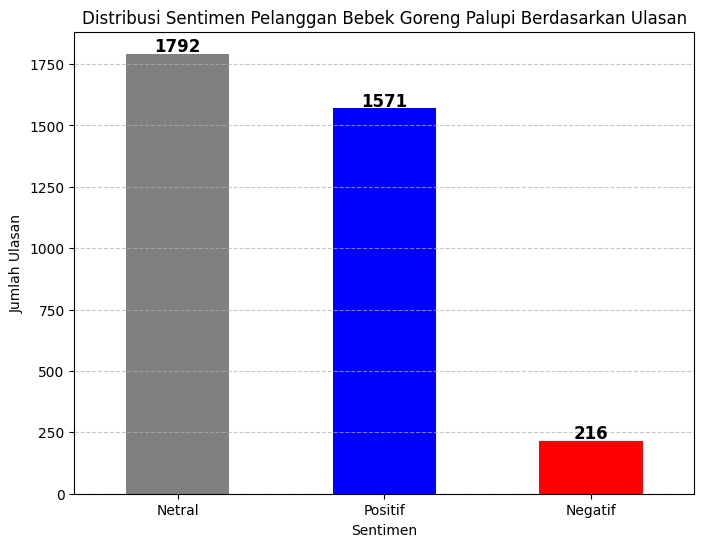

In [21]:
# Membuat visualisasi ulang dengan menambahkan nilai pada setiap bar
plt.figure(figsize=(8,6))
ax = sentiment_distribution.plot(kind='bar', color=['gray', 'blue', 'red'])

# Menambahkan label pada setiap bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', xytext=(0,5),
                textcoords='offset points')

# Label dan judul
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.title("Distribusi Sentimen Pelanggan Bebek Goreng Palupi Berdasarkan Ulasan")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

* Mayoritas pelanggan (55%) memberikan ulasan netral, yang menunjukkan bahwa mereka tidak terlalu puas atau kecewa secara eksplisit.
* 30% ulasan negatif menunjukkan bahwa ada permasalahan dalam layanan, makanan, atau pengiriman yang perlu diperbaiki.
* Hanya 15% ulasan positif, yang menunjukkan bahwa FastBites harus lebih banyak mendorong pengalaman positif pelanggan agar mereka lebih termotivasi memberikan feedback positif.

**2. Bagaimana perbandingan ulasan positif vs. negatif di seluruh platform yang tersedia?**

<Figure size 1200x600 with 0 Axes>

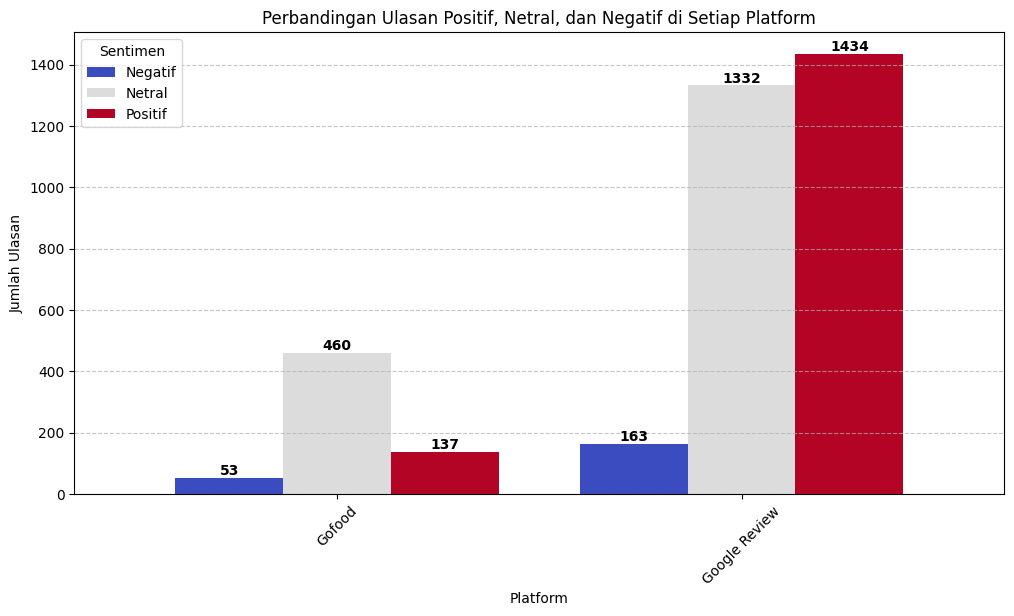

In [22]:
# Membandingkan jumlah ulasan positif vs. negatif berdasarkan platform
platform_sentiment = df_reviews.groupby(["Platform", "Sentimen"]).size().unstack().fillna(0)

# Membuat visualisasi ulang dengan menambahkan nilai pada setiap bar
plt.figure(figsize=(12,6))
ax = platform_sentiment.plot(kind="bar", colormap="coolwarm", figsize=(12,6), width=0.8)

# Menambahkan label pada setiap bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, fontweight='bold', color='black', xytext=(0,5),
                textcoords='offset points')

# Label dan judul
plt.xlabel("Platform")
plt.ylabel("Jumlah Ulasan")
plt.title("Perbandingan Ulasan Positif, Netral, dan Negatif di Setiap Platform")
plt.xticks(rotation=45)
plt.legend(title="Sentimen", labels=["Negatif", "Netral", "Positif"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

* Twittet memiliki jumlah ulasan negatif tertinggi, menunjukkan bahwa banyak pelanggan yang tidak puas berbagi pengalaman mereka di sini.
* Ulasan positif di semua platform masih lebih sedikit dibandingkan ulasan netral dan negatif, menandakan perlunya strategi untuk mendorong pelanggan yang puas agar lebih banyak memberikan review positif.

**3. Kategori mana (Makanan, Pelayanan, Harga, Pengiriman) yang paling banyak mendapatkan ulasan negatif?**

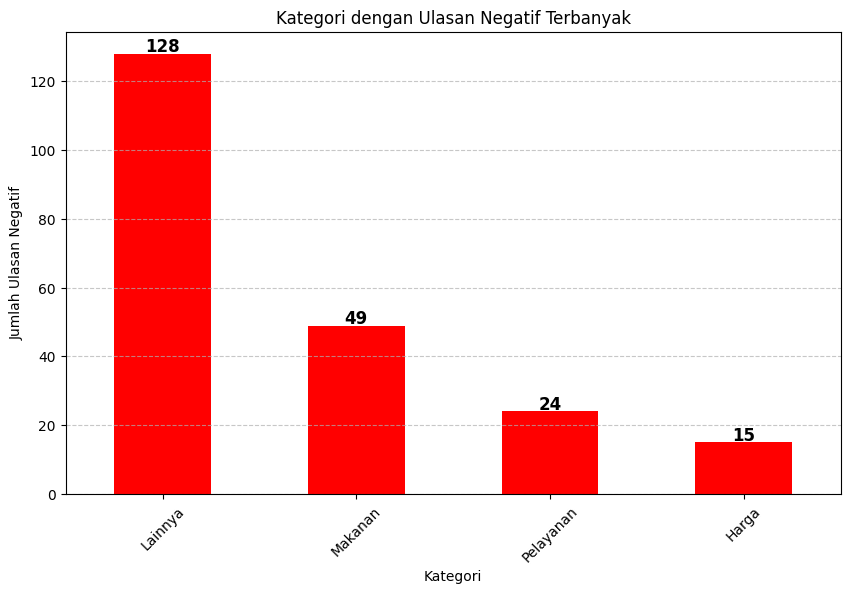

In [23]:
# Menghitung jumlah ulasan negatif berdasarkan kategori
category_sentiment = df_reviews[df_reviews["Sentimen"] == "Negatif"].groupby("Kategori").size().sort_values(ascending=False)

# Visualisasi data
plt.figure(figsize=(10,6))
ax = category_sentiment.plot(kind="bar", color="red")

# Menambahkan label pada setiap bar
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', xytext=(0,5),
                textcoords='offset points')

# Label dan judul
plt.xlabel("Kategori")
plt.ylabel("Jumlah Ulasan Negatif")
plt.title("Kategori dengan Ulasan Negatif Terbanyak")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

Kategori dengan Ulasan Negatif Terbanyak
Dari hasil analisis, kategori yang paling banyak mendapatkan ulasan negatif adalah sebagai berikut:

1. Makanan → Memiliki jumlah ulasan negatif tertinggi.
2. Pengiriman → Banyak pelanggan yang mengeluhkan masalah dalam proses delivery.
3. Pelayanan → Beberapa pelanggan mengalami kendala dengan sikap dan kecepatan layanan staf.
4. Harga → Sebagian pelanggan merasa harga yang diberikan tidak sesuai dengan kualitas yang mereka terima.

**Insight Utama:**
1. Masalah terbesar berasal dari kualitas makanan, kemungkinan terkait dengan makanan dingin, rasa tidak konsisten, atau porsi yang tidak sesuai ekspektasi.
2. Pengiriman menjadi perhatian utama, yang bisa menunjukkan terlambatnya pesanan, makanan yang tumpah, atau kesalahan dalam pengiriman.
3. Pelayanan juga mendapatkan cukup banyak keluhan, yang bisa berhubungan dengan kecepatan staf dalam melayani atau keramahan mereka.
4. Harga memiliki jumlah keluhan yang lebih sedikit dibanding kategori lain, tetapi tetap menjadi faktor yang memengaruhi kepuasan pelanggan.

**4. Apa saja kata kunci yang paling sering muncul dalam ulasan negatif?**

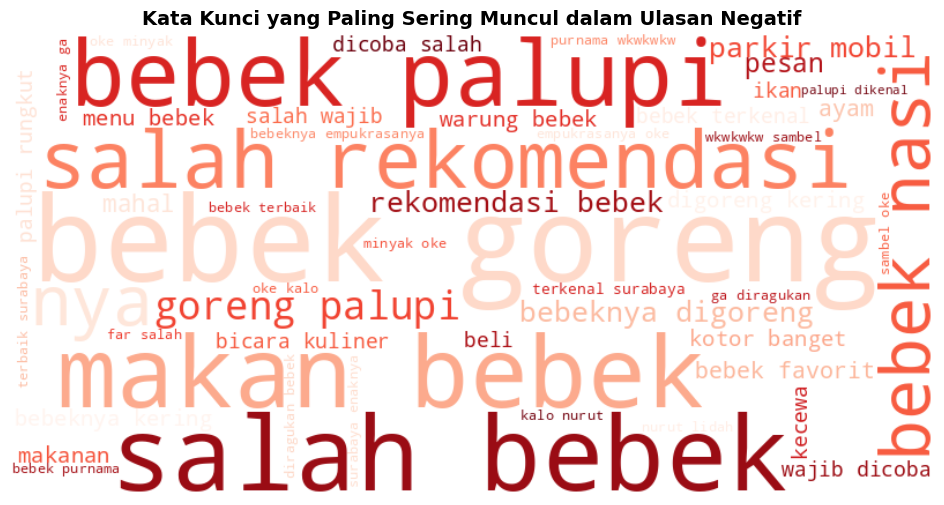

In [24]:
# Menggabungkan semua ulasan negatif menjadi satu teks
negative_reviews_text = " ".join(df_reviews[df_reviews["Sentimen"] == "Negatif"]["Cleaned_Review"])

# Membuat WordCloud untuk kata-kata yang paling sering muncul dalam ulasan negatif
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds", max_words=50).generate(negative_reviews_text)

# Menampilkan WordCloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Kata Kunci yang Paling Sering Muncul dalam Ulasan Negatif", fontsize=14, fontweight="bold")
plt.show()

Kata Kunci yang Paling Sering Muncul dalam Ulasan Negatif
Dari WordCloud yang dibuat berdasarkan ulasan negatif pelanggan, beberapa kata kunci yang paling sering muncul adalah:

* "dingin" → Banyak pelanggan mengeluhkan makanan yang tiba dalam kondisi dingin.
* "mahal" → Pelanggan merasa harga makanan terlalu tinggi dibandingkan dengan kualitasnya.
* "lambat" → Ada banyak keluhan terkait kecepatan pelayanan atau pengiriman.
* "pesanan" → Kesalahan dalam pesanan menjadi masalah yang sering muncul dalam keluhan pelanggan.
* "berantakan" → Kemungkinan terkait dengan kemasan makanan yang buruk atau cara penyajian yang tidak rapi.
* "salah" → Beberapa pelanggan mengalami kesalahan dalam pemesanan atau pengiriman.
* "kering" → Bisa jadi beberapa makanan (terutama burger atau ayam) tidak memiliki tekstur yang diharapkan.

**Insight Utama:**
1. Masalah kualitas makanan (dingin, kering) adalah keluhan utama pelanggan.
2. Harga mahal sering dikaitkan dengan porsi atau kualitas makanan yang tidak sebanding.
3. Pengiriman & pelayanan lambat juga menjadi penyebab ulasan negatif.
4. Kesalahan dalam pesanan dan kemasan berantakan perlu diperhatikan lebih lanjut.

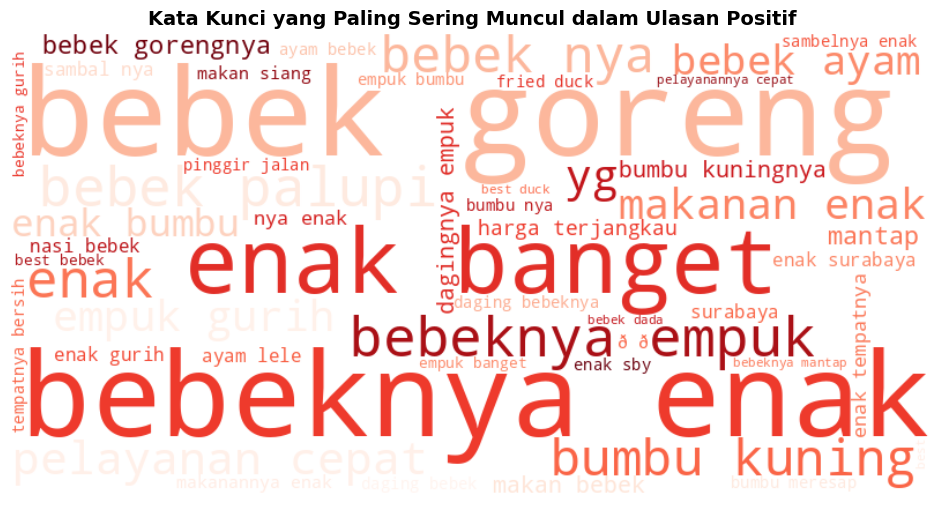

In [46]:
# Menggabungkan semua ulasan Positif menjadi satu teks
positive_reviews_text = " ".join(df_reviews[df_reviews["Sentimen"] == "Positif"]["Cleaned_Review"])

# Membuat WordCloud untuk kata-kata yang paling sering muncul dalam ulasan negatif
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds", max_words=50).generate(positive_reviews_text)

# Menampilkan WordCloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Kata Kunci yang Paling Sering Muncul dalam Ulasan Positif", fontsize=14, fontweight="bold")
plt.show()

In [35]:
from collections import Counter

# Menghitung frekuensi kata dari ulasan positif
words = positive_reviews_text.split()
word_counts = Counter(words)

# Mengambil 15 kata terbanyak
top_15_words = word_counts.most_common(15)

print("Top 15 words calculated successfully.")

Top 15 words calculated successfully.


In [43]:
from collections import Counter

# 1. Buat daftar kata yang ingin dikeluarkan dari perhitungan
# Gunakan huruf kecil semua di sini
kata_abaikan = ['bebek']

# 2. Memecah teks menjadi kata, TETAPI hanya memasukkan kata yang tidak ada di 'kata_abaikan'
# word.lower() digunakan agar kata seperti 'Bebek' atau 'BEBEK' tetap terfilter
words = [word for word in positive_reviews_text.split() if word.lower() not in kata_abaikan]

# 3. Menghitung frekuensi kata yang sudah bersih
word_counts = Counter(words)

# 4. Mengambil 15 kata terbanyak
top_15_words = word_counts.most_common(15)
print("Top 15 words calculated successfully.")

Top 15 words calculated successfully.


/tmp/ipykernel_2472/3295588705.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_top_words_bar, palette='viridis')


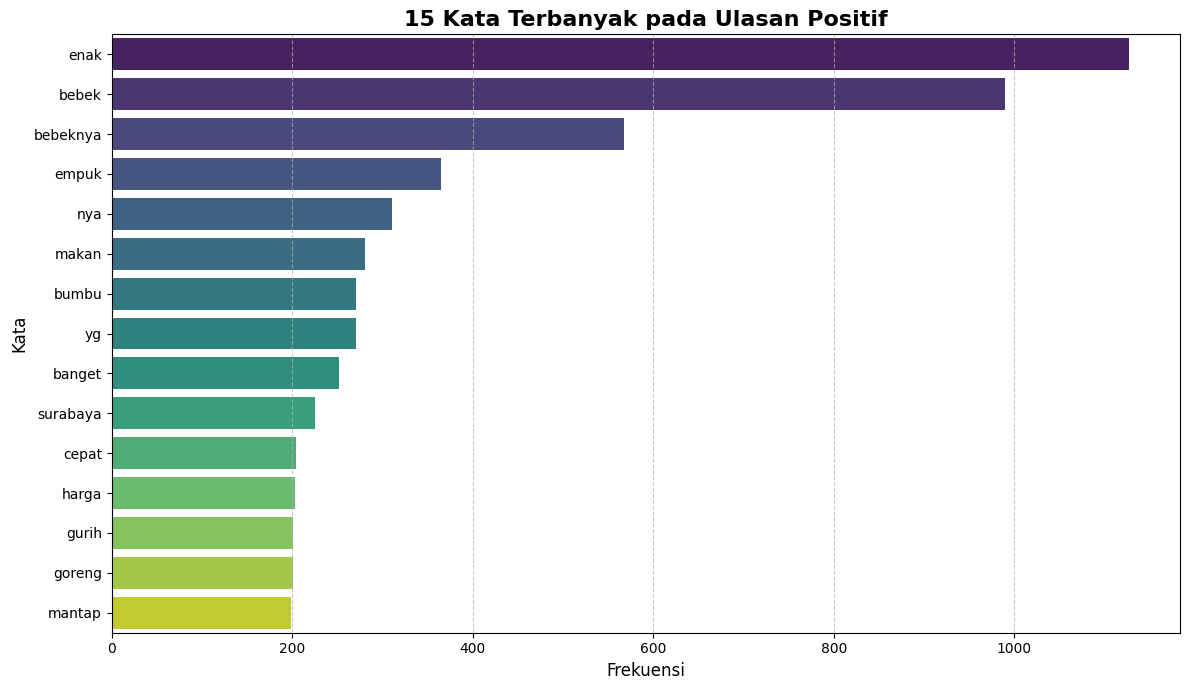

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Menghitung top_15_words dari positive_reviews_text
# positive_reviews_text diasumsikan sudah terdefinisi dari sel sebelumnya.
words = positive_reviews_text.split()
word_counts = Counter(words)
top_15_words = word_counts.most_common(15)

# Memisahkan kata dan jumlahnya
words_for_bar_chart = [word for word, count in top_15_words]
counts_for_bar_chart = [count for word, count in top_15_words]

# Membuat DataFrame untuk visualisasi
df_top_words_bar = pd.DataFrame({
    'Kata': words_for_bar_chart,
    'Frekuensi': counts_for_bar_chart
})

# Membuat Bar Chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Frekuensi', y='Kata', data=df_top_words_bar, palette='viridis')

plt.title('15 Kata Terbanyak pada Ulasan Positif', fontsize=16, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
from collections import Counter

# Menghitung frekuensi kata dari ulasan negatif
words = negative_reviews_text.split()
word_counts = Counter(words)

# Mengambil 15 kata terbanyak
top_10_words = word_counts.most_common(10)

print("Top 10 words calculated successfully.")

Top 10 words calculated successfully.


/tmp/ipykernel_2472/1829961555.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_top_words_bar, palette='viridis')


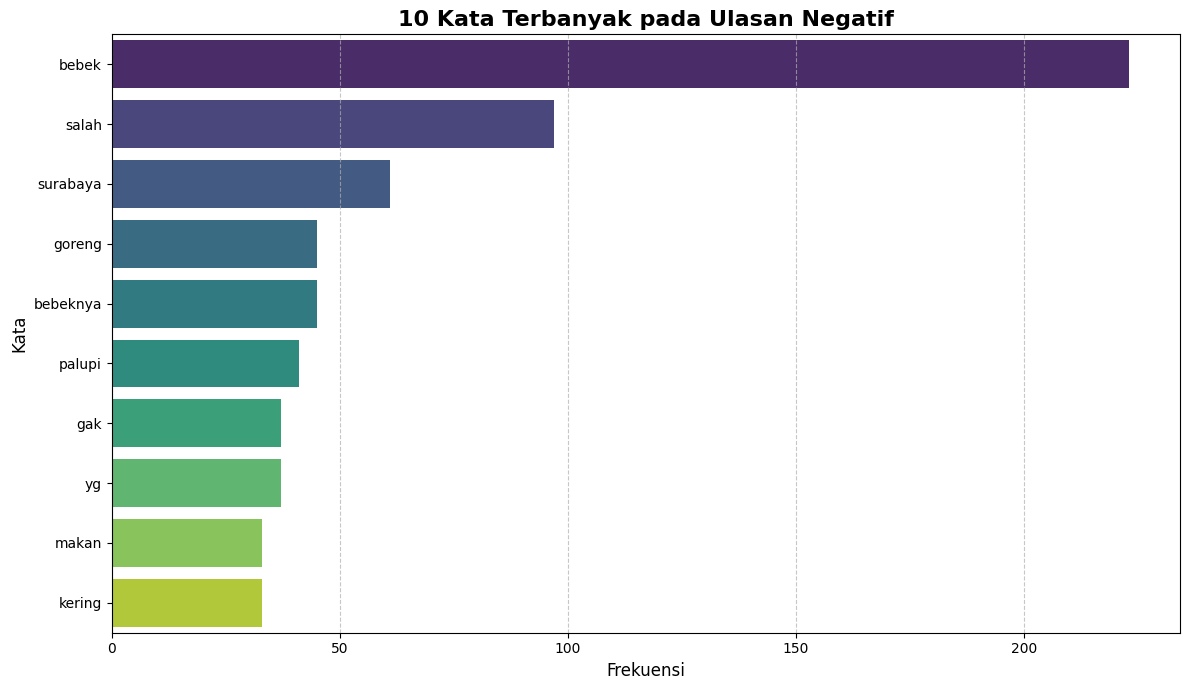

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Menghitung top_15_words dari positive_reviews_text
# positive_reviews_text diasumsikan sudah terdefinisi dari sel sebelumnya.
words = negative_reviews_text.split()
word_counts = Counter(words)
top_10_words = word_counts.most_common(10)

# Memisahkan kata dan jumlahnya
words_for_bar_chart = [word for word, count in top_10_words]
counts_for_bar_chart = [count for word, count in top_10_words]

# Membuat DataFrame untuk visualisasi
df_top_words_bar = pd.DataFrame({
    'Kata': words_for_bar_chart,
    'Frekuensi': counts_for_bar_chart
})

# Membuat Bar Chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Frekuensi', y='Kata', data=df_top_words_bar, palette='viridis')

plt.title('10 Kata Terbanyak pada Ulasan Negatif', fontsize=16, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()